# Data Loading and Understanding

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

admissions = pd.read_csv("admissions.csv")
patients = pd.read_csv("patients.csv")
diagnoses = pd.read_csv("diagnoses.csv")
billing = pd.read_csv("billing.csv")
hospitals = pd.read_csv("hospitals.csv")

In [110]:
for name, df in {
    "Admissions": admissions,
    "Patients": patients,
    "Diagnoses": diagnoses,
    "Billing": billing,
    "Hospitals": hospitals
}.items():

    print("="*60)
    print(name)
    print(df.shape)
    print(df.columns.tolist())

Admissions
(120000, 17)
['admission_id', 'patient_id', 'admit_date', 'discharge_date', 'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp', 'readmitted_30d', 'readmitted_7d']
Patients
(86400, 8)
['patient_id', 'age', 'gender', 'state', 'bpl_card', 'insurance_type', 'comorbidity_count', 'prev_admissions']
Diagnoses
(271341, 6)
['diag_id', 'admission_id', 'icd10_code', 'diag_desc', 'diag_rank', 'diag_category']
Billing
(120000, 6)
['bill_id', 'admission_id', 'total_cost_inr', 'govt_subsidy_inr', 'out_of_pocket_inr', 'cost_category']
Hospitals
(33, 6)
['hospital_id', 'name', 'state', 'tier', 'beds', 'teaching']


In [111]:
admissions.head()

,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0


In [112]:
patients.head()

,patient_id,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
0,2b179f89-9af7-45cf-86b4-3e01a47a3b7b,36,F,Telangana,False,Private,0,0
1,ecaeb9f3-d263-4712-b9b6-3312af5626ca,56,F,Uttar Pradesh,False,ESI,0,0
2,0160a5b6-877e-41e6-b84a-a2a51b367a36,67,F,Telangana,False,ESI,3,0
3,216875fa-b49d-4c47-8c8d-7191ba34ac06,53,M,Haryana,False,Ayushman,3,0
4,a2f3181d-e3f2-4fd3-8057-05a492ffcfb2,60,M,Maharashtra,True,Ayushman,4,1


In [113]:
diagnoses.head()

,diag_id,admission_id,icd10_code,diag_desc,diag_rank,diag_category
0,3b448b98-6b78-4c7c-94c1-f832581c5052,bcb311d6-0808-498f-8ae1-11abe1fbc08e,E87,Metabolic / electrolyte disorder,1,Endocrine
1,137c0404-f1b6-4aca-95f5-2217812a6975,996ac6db-a192-46a0-b536-503a1c57994b,J45,Asthma,1,Respiratory
2,4bfb76a1-12ed-4cbd-b905-34d4bf3196f0,cc4849fa-b740-487b-beda-3086a18273c0,G40,Epilepsy,1,Neurological
3,754ec3d2-e940-4342-9e1d-d88a9acec626,cc4849fa-b740-487b-beda-3086a18273c0,A15,Pulmonary tuberculosis,2,Infectious
4,f4fa0d7b-0a68-4dd9-b7cf-db15c6bf3812,cc4849fa-b740-487b-beda-3086a18273c0,I48,Atrial fibrillation,3,Cardiovascular


In [114]:
billing.head()

,bill_id,admission_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category
0,68e19242-4126-4a7a-afa2-9e6035cdcffa,bcb311d6-0808-498f-8ae1-11abe1fbc08e,18492,16630,1862,Lab
1,b740202e-1d7a-45b4-9575-21b35e219e37,996ac6db-a192-46a0-b536-503a1c57994b,1001,0,1001,Lab
2,f60fecaa-e769-42ea-bee8-58198bdd1208,cc4849fa-b740-487b-beda-3086a18273c0,59696,48650,11046,Room
3,32f41176-c088-4e9a-aa81-ae40f91b912a,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,72588,0,72588,Lab
4,cf80fba9-7fec-4b2e-b548-037a43dcf93c,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,9510,0,9510,Lab


In [115]:
hospitals.head()

,hospital_id,name,state,tier,beds,teaching
0,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Government General Hospital Maharashtra,Maharashtra,tier2,314,True
1,3d59f4a6-ce9c-4945-8f1f-5929f09a7836,Government General Hospital Uttar Pradesh,Uttar Pradesh,tier2,481,True
2,aac12881-4dea-42f3-bf32-8add9d5eee49,Government General Hospital Tamil Nadu,Tamil Nadu,tier2,428,True
3,28879338-cd09-48bb-bedb-730b8ee8ab4e,Government General Hospital Karnataka,Karnataka,tier2,304,True
4,2f5c9dbb-cef7-46a2-8f35-ac5bdc0232c6,Government General Hospital West Bengal,West Bengal,tier2,632,True


In [116]:
admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   admission_id    120000 non-null  object 
 1   patient_id      120000 non-null  object 
 2   admit_date      120000 non-null  object 
 3   discharge_date  120000 non-null  object 
 4   los_days        120000 non-null  int64  
 5   admit_type      120000 non-null  object 
 6   ward_type       120000 non-null  object 
 7   hospital_id     120000 non-null  object 
 8   discharge_type  120000 non-null  object 
 9   num_procedures  120000 non-null  int64  
 10  charlson_index  120000 non-null  int64  
 11  hba1c           120000 non-null  float64
 12  creatinine      120000 non-null  float64
 13  haemoglobin     120000 non-null  float64
 14  systolic_bp     120000 non-null  int64  
 15  readmitted_30d  120000 non-null  int64  
 16  readmitted_7d   120000 non-null  int64  
dtypes: float64

In [117]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_id         86400 non-null  object
 1   age                86400 non-null  int64 
 2   gender             86400 non-null  object
 3   state              86400 non-null  object
 4   bpl_card           86400 non-null  bool  
 5   insurance_type     61685 non-null  object
 6   comorbidity_count  86400 non-null  int64 
 7   prev_admissions    86400 non-null  int64 
dtypes: bool(1), int64(3), object(4)
memory usage: 4.7+ MB


In [118]:
diagnoses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271341 entries, 0 to 271340
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   diag_id        271341 non-null  object
 1   admission_id   271341 non-null  object
 2   icd10_code     271341 non-null  object
 3   diag_desc      271341 non-null  object
 4   diag_rank      271341 non-null  int64 
 5   diag_category  271341 non-null  object
dtypes: int64(1), object(5)
memory usage: 12.4+ MB


In [119]:
billing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   bill_id            120000 non-null  object
 1   admission_id       120000 non-null  object
 2   total_cost_inr     120000 non-null  int64 
 3   govt_subsidy_inr   120000 non-null  int64 
 4   out_of_pocket_inr  120000 non-null  int64 
 5   cost_category      120000 non-null  object
dtypes: int64(3), object(3)
memory usage: 5.5+ MB


In [120]:
hospitals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   hospital_id  33 non-null     object
 1   name         33 non-null     object
 2   state        33 non-null     object
 3   tier         33 non-null     object
 4   beds         33 non-null     int64 
 5   teaching     33 non-null     bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 1.5+ KB


# Data Integration & Data Quality Assessment.

In [121]:
dfs = {
    "Admissions": admissions,
    "Patients": patients,
    "Diagnoses": diagnoses,
    "Billing": billing,
    "Hospitals": hospitals
}

for name, df in dfs.items():
    print("="*70)
    print(name)
    print("\nShape :", df.shape)
    print("\nMissing Values")
    print(df.isnull().sum())
    print("\nDuplicate Rows :", df.duplicated().sum())

Admissions

Shape : (120000, 17)

Missing Values
admission_id      0
patient_id        0
admit_date        0
discharge_date    0
los_days          0
admit_type        0
ward_type         0
hospital_id       0
discharge_type    0
num_procedures    0
charlson_index    0
hba1c             0
creatinine        0
haemoglobin       0
systolic_bp       0
readmitted_30d    0
readmitted_7d     0
dtype: int64

Duplicate Rows : 0
Patients

Shape : (86400, 8)

Missing Values
patient_id               0
age                      0
gender                   0
state                    0
bpl_card                 0
insurance_type       24715
comorbidity_count        0
prev_admissions          0
dtype: int64

Duplicate Rows : 0
Diagnoses

Shape : (271341, 6)

Missing Values
diag_id          0
admission_id     0
icd10_code       0
diag_desc        0
diag_rank        0
diag_category    0
dtype: int64

Duplicate Rows : 0
Billing

Shape : (120000, 6)

Missing Values
bill_id              0
admission_id         0

In [122]:
admissions["admission_id"].nunique(), len(admissions)

(120000, 120000)

In [123]:
patients["patient_id"].nunique(), len(patients)

(86400, 86400)

In [124]:
billing["admission_id"].nunique(), len(billing)

(120000, 120000)

In [125]:
hospitals["hospital_id"].nunique(), len(hospitals)

(33, 33)

In [126]:
diagnoses.groupby("admission_id").size().describe()

,0
count,120000.000000
mean,2.261175
std,1.157536
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


In [127]:
diagnoses["diag_rank"].value_counts().sort_index()

,count
diag_rank,
1,120000
2,77128
3,48270
4,25943


In [128]:
diagnoses["diag_category"].value_counts()

,count
diag_category,
Cardiovascular,53410
Endocrine,35491
Respiratory,30648
Infectious,30397
Gastrointestinal,23601
Neoplasm,21776
Injury,17278
Neurological,17111
Genitourinary,16591


In [129]:
patients["insurance_type"] = patients["insurance_type"].fillna("Unknown")

Patients
        \
         \
Admissions ------ Billing
       \            /
        \          /
       Hospitals
            \
             \
       Primary Diagnosis
             \
        Diagnosis Count

        ↓↓↓↓↓↓↓↓↓↓↓↓

        MASTER DATASET
(120000 rows × 43 columns)

In [130]:
primary_diag = diagnoses[diagnoses["diag_rank"] == 1][
    ["admission_id", "icd10_code", "diag_desc", "diag_category"]
]

primary_diag

,admission_id,icd10_code,diag_desc,diag_category
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,E87,Metabolic / electrolyte disorder,Endocrine
1,996ac6db-a192-46a0-b536-503a1c57994b,J45,Asthma,Respiratory
2,cc4849fa-b740-487b-beda-3086a18273c0,G40,Epilepsy,Neurological
5,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,I50,Heart failure,Cardiovascular
6,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,C50,Malignant neoplasm — breast,Neoplasm
...,...,...,...,...
271331,092b2041-97a4-480c-bd0e-6efc2cc25b25,I10,Essential hypertension,Cardiovascular
271332,36829aa2-4076-43f4-80e3-7e7877536933,G35,Multiple sclerosis,Neurological
271335,3fdc0376-8c2a-4219-b7bf-5c8c9f7261d4,I50,Heart failure,Cardiovascular
271337,32885a57-00af-4cba-94b5-6cbba3829e63,G40,Epilepsy,Neurological


In [131]:
diag_count = (
    diagnoses.groupby("admission_id")
    .size()
    .reset_index(name="diagnosis_count")
)

In [132]:
master_df = admissions.merge(
    patients,
    on="patient_id",
    how="left"
)

In [133]:
master_df = master_df.merge(
    billing,
    on="admission_id",
    how="left")

In [134]:
master_df = master_df.merge(
    hospitals,
    on="hospital_id",
    how="left",
    suffixes=("", "_hospital"))

In [135]:
# Merge Primary Diagnosis
master_df = master_df.merge(
    primary_diag,
    on="admission_id",
    how="left"
      )

In [136]:
master_df = master_df.merge(
    diag_count,
    on="admission_id",
    how="left"
)

In [137]:
master_df.shape

(120000, 38)

# Exploratory Data Analysis

In [138]:
master_df["readmitted_30d"].value_counts()

,count
readmitted_30d,
0,105790
1,14210


In [139]:
readmission_counts = master_df["readmitted_30d"].value_counts()

readmission_counts

,count
readmitted_30d,
0,105790
1,14210


In [140]:
master_df["readmitted_30d"].value_counts(normalize=True)*100

,proportion
readmitted_30d,
0,88.158333
1,11.841667


In [141]:
labels = ["Not Readmitted", "Readmitted"]
sizes = readmission_counts.values

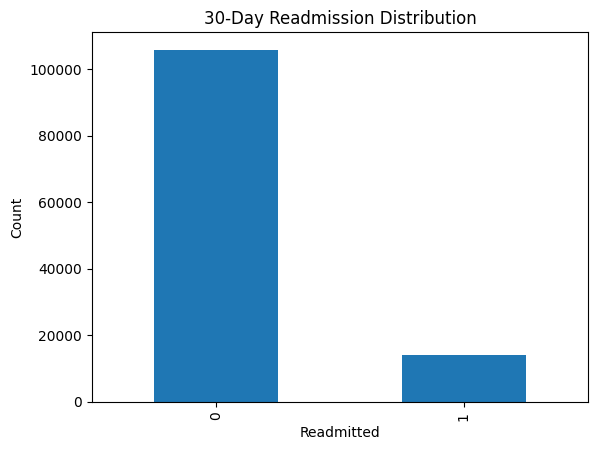

In [142]:
master_df["readmitted_30d"].value_counts().plot(kind="bar")

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.show()

# Observation :

The majority of admissions were not followed by a 30-day readmission, while a smaller proportion resulted in readmission.

# Business Insight :

Since only a subset of patients is readmitted, hospitals should focus preventive resources on identifying high-risk patients rather than applying intensive interventions to all discharged patients. This justifies the use of predictive analytics for targeted post-discharge care.

In [143]:
master_df.select_dtypes(include=["int64","float64"]).columns

Index(['los_days', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine',
       'haemoglobin', 'systolic_bp', 'readmitted_30d', 'readmitted_7d', 'age',
       'comorbidity_count', 'prev_admissions', 'total_cost_inr',
       'govt_subsidy_inr', 'out_of_pocket_inr', 'beds', 'diagnosis_count'],
      dtype='object')

In [144]:
master_df.describe().T

,count,mean,std,min,25%,50%,75%,max
los_days,120000.0,6.852708,5.708269,1.0,3.00,5.00,9.00,90.0
num_procedures,120000.0,1.523742,1.542197,0.0,0.00,1.00,2.00,15.0
charlson_index,120000.0,1.894858,1.610380,0.0,0.00,2.00,3.00,6.0
hba1c,120000.0,5.869862,1.061662,4.0,5.30,5.70,6.10,14.3
creatinine,120000.0,1.070463,0.896135,0.4,0.77,0.91,1.10,15.0
haemoglobin,120000.0,11.840079,2.171929,4.0,10.40,11.90,13.30,18.0
systolic_bp,120000.0,134.628075,20.756544,70.0,120.00,134.00,148.00,220.0
readmitted_30d,120000.0,0.118417,0.323102,0.0,0.00,0.00,0.00,1.0
readmitted_7d,120000.0,0.008383,0.091176,0.0,0.00,0.00,0.00,1.0
age,120000.0,48.049867,21.635289,0.0,36.00,51.00,63.00,95.0


# Number of Procedures (num_procedures)

In [178]:
master_df["num_procedures"].describe()

,num_procedures
count,120000.000000
mean,1.523742
std,1.542197
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,15.000000


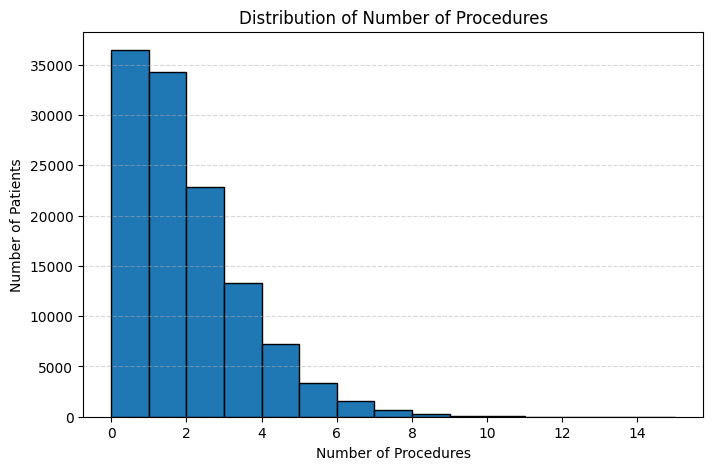

In [179]:
plt.figure(figsize=(8,5))

plt.hist(master_df["num_procedures"], bins=15, edgecolor="black")

plt.title("Distribution of Number of Procedures")
plt.xlabel("Number of Procedures")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

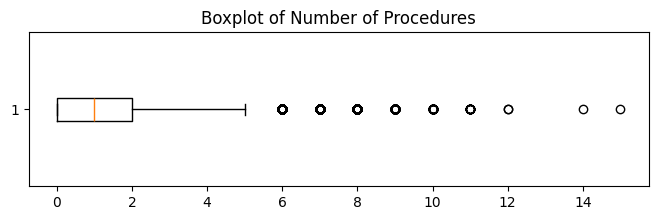

In [180]:
plt.figure(figsize=(8,2))

plt.boxplot(master_df["num_procedures"], vert=False)

plt.title("Boxplot of Number of Procedures")

plt.show()

In [145]:
master_df["age"].describe()

,age
count,120000.000000
mean,48.049867
std,21.635289
min,0.000000
25%,36.000000
50%,51.000000
75%,63.000000
max,95.000000


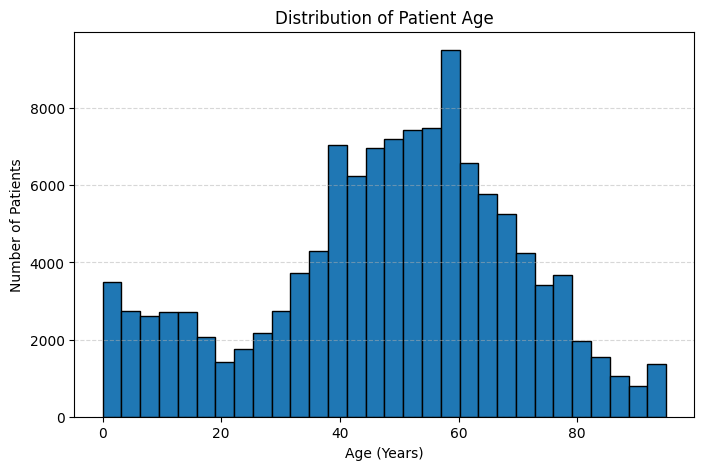

In [146]:
plt.figure(figsize=(8,5))
plt.hist(master_df["age"], bins=30, edgecolor="black")

plt.title("Distribution of Patient Age")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

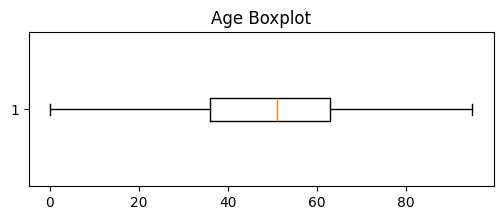

In [147]:
plt.figure(figsize=(6,2))
plt.boxplot(master_df["age"], vert=False)

plt.title("Age Boxplot")
plt.show()

# Observation :

 Patient ages range from 0 to around 95 years.

 The majority of admissions occur between 40 and 70 years.

 The highest concentration of patients is around 55–60 years.

 There are comparatively fewer admissions among children and very elderly patients.

 The distribution is slightly left-skewed (negatively skewed) because there are relatively more younger-age observations extending the left tail, while the peak is around the late 50s.

 No outliers are present, indicating there are no unusually extreme ages according to the IQR rule.

# Insight

The hospital primarily serves middle-aged and older adults, suggesting that chronic diseases requiring hospitalization are more common in this age group. Since advancing age is often associated with multiple comorbidities and slower recovery, age is expected to be an important predictor of 30-day hospital readmission.

# Length Of Stay

In [148]:
master_df["los_days"].describe()

,los_days
count,120000.000000
mean,6.852708
std,5.708269
min,1.000000
25%,3.000000
50%,5.000000
75%,9.000000
max,90.000000


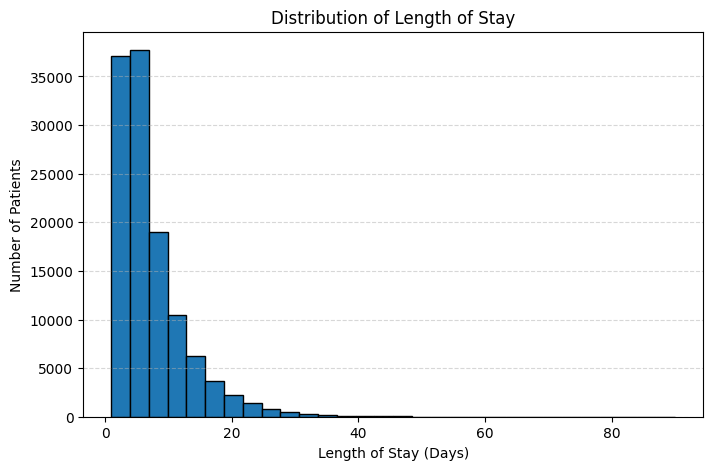

In [149]:
plt.figure(figsize=(8,5))

plt.hist(master_df["los_days"], bins=30, edgecolor="black")

plt.title("Distribution of Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

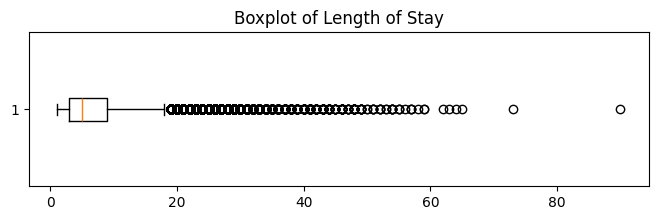

In [150]:
plt.figure(figsize=(8,2))

plt.boxplot(master_df["los_days"], vert=False)

plt.title("Boxplot of Length of Stay")

plt.show()

# Outlier Treatment :

The observed outliers were retained because prolonged hospital stays are clinically valid and represent patients with more complex medical conditions rather than erroneous data.

# Observation :

The distribution of Length of Stay (LOS) is highly right-skewed. Most patients remain hospitalized for less than 10 days, while only a small proportion experience prolonged hospital stays. The boxplot reveals several high-value observations corresponding to extended admissions.


# Key Insight:

Although most patients are discharged within a week, patients with extended hospital stays represent a small but clinically important group that may require targeted follow-up to reduce readmission risk.

# charlson_index :

The Charlson Comorbidity Index summarizes the burden of chronic diseases into a single score. Patients with higher scores generally have more complex medical conditions and are expected to have a higher probability of hospital readmission. Therefore, this variable is likely to be one of the strongest predictors in the machine learning model.

In [151]:
master_df["charlson_index"].describe()

,charlson_index
count,120000.000000
mean,1.894858
std,1.610380
min,0.000000
25%,0.000000
50%,2.000000
75%,3.000000
max,6.000000


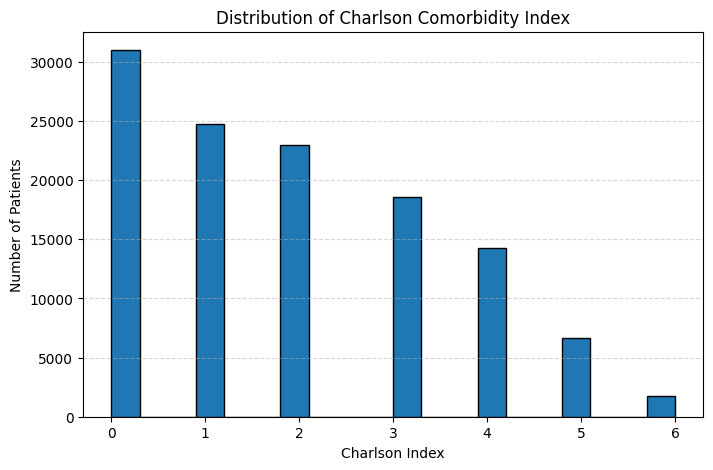

In [152]:
plt.figure(figsize=(8,5))

plt.hist(master_df["charlson_index"], bins=20, edgecolor="black")

plt.title("Distribution of Charlson Comorbidity Index")
plt.xlabel("Charlson Index")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

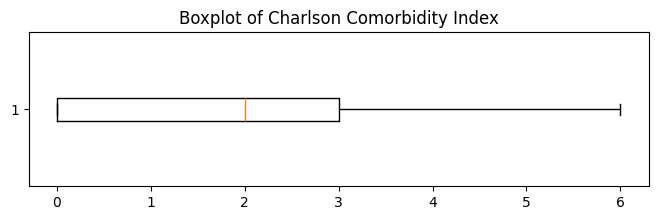

In [153]:
plt.figure(figsize=(8,2))

plt.boxplot(master_df["charlson_index"], vert=False)

plt.title("Boxplot of Charlson Comorbidity Index")

plt.show()

No outlier treatment was required.

# Observation :

The Charlson Comorbidity Index ranges from 0 to 6.

Most patients have a low comorbidity burden (0–2).

As the Charlson Index increases, the number of patients steadily decreases.

Very few patients have a score of 5 or 6, indicating severe disease burden.

# Key Insight :

Patients with higher Charlson Comorbidity Index scores represent a clinically vulnerable population with multiple chronic conditions. These patients are likely to require additional medical attention after discharge and may have a higher probability of 30-day hospital readmission.

# hba1c

HbA1c (Glycated Hemoglobin) measures a person's average blood sugar level over the last 2–3 months.

In [154]:
master_df["hba1c"].describe()

,hba1c
count,120000.000000
mean,5.869862
std,1.061662
min,4.000000
25%,5.300000
50%,5.700000
75%,6.100000
max,14.300000


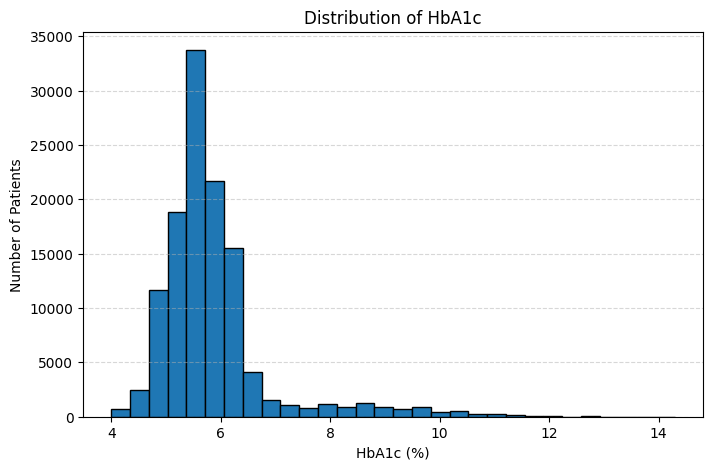

In [155]:
plt.figure(figsize=(8,5))

plt.hist(master_df["hba1c"], bins=30, edgecolor="black")

plt.title("Distribution of HbA1c")
plt.xlabel("HbA1c (%)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

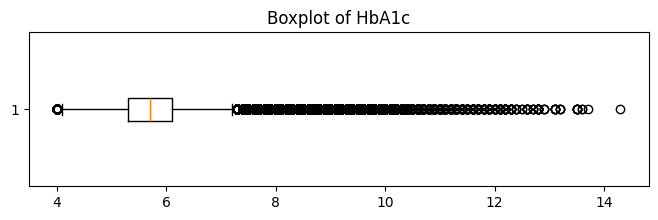

In [156]:
plt.figure(figsize=(8,2))

plt.boxplot(master_df["hba1c"], vert=False)

plt.title("Boxplot of HbA1c")

plt.show()

High HbA1c values were retained because they represent genuine clinical conditions rather than erroneous observations. These patients are particularly relevant to the objective of predicting hospital readmission.

# Observation :

The HbA1c distribution is positively skewed, with most patients having values between 5% and 6.5%. A small proportion of patients exhibit substantially higher HbA1c levels, indicating poor long-term blood glucose control.

# Key Insight :

Elevated HbA1c values identify patients with poorly controlled diabetes, who may be more susceptible to complications after discharge. Targeted diabetes management and follow-up interventions for these patients could help reduce 30-day hospital readmissions.

# Creatinine

Creatinine is a blood test used to assess kidney function.

In [157]:
master_df["creatinine"].describe()

,creatinine
count,120000.000000
mean,1.070463
std,0.896135
min,0.400000
25%,0.770000
50%,0.910000
75%,1.100000
max,15.000000


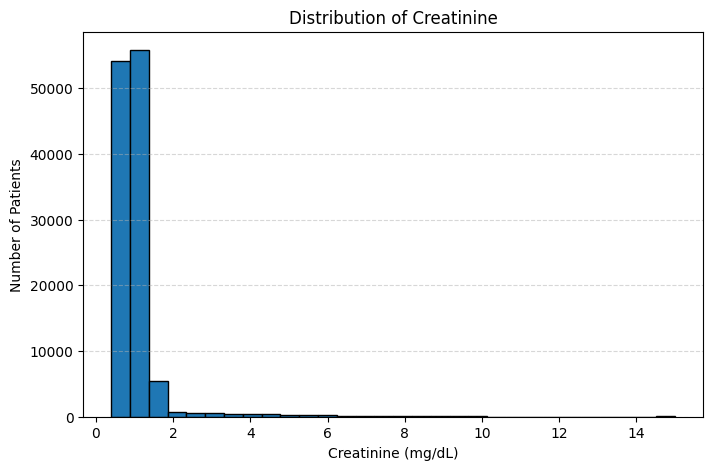

In [158]:
plt.figure(figsize=(8,5))

plt.hist(master_df["creatinine"], bins=30, edgecolor="black")

plt.title("Distribution of Creatinine")
plt.xlabel("Creatinine (mg/dL)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

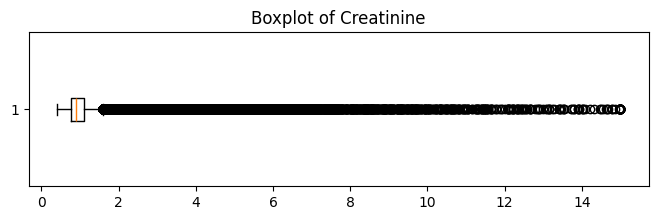

In [159]:
plt.figure(figsize=(8,2))

plt.boxplot(master_df["creatinine"], vert=False)

plt.title("Boxplot of Creatinine")

plt.show()

Elevated creatinine values were retained because they represent clinically meaningful kidney dysfunction rather than erroneous measurements. These observations are important for developing an effective readmission prediction model.

# Observation :

The creatinine distribution is highly positively skewed, with most patients having values within the normal clinical range. A relatively small proportion of patients exhibit markedly elevated creatinine levels, indicating impaired kidney function.

# Key Insight :

Patients with elevated creatinine levels may have underlying kidney disease or acute renal impairment, increasing the complexity of clinical management. Identifying these patients before discharge can help hospitals prioritize follow-up care and potentially reduce 30-day readmissions.

# Haemoglobin :

Haemoglobin (Hb) is the protein in red blood cells that carries oxygen throughout the body.

In [160]:
master_df["haemoglobin"].describe()

,haemoglobin
count,120000.000000
mean,11.840079
std,2.171929
min,4.000000
25%,10.400000
50%,11.900000
75%,13.300000
max,18.000000


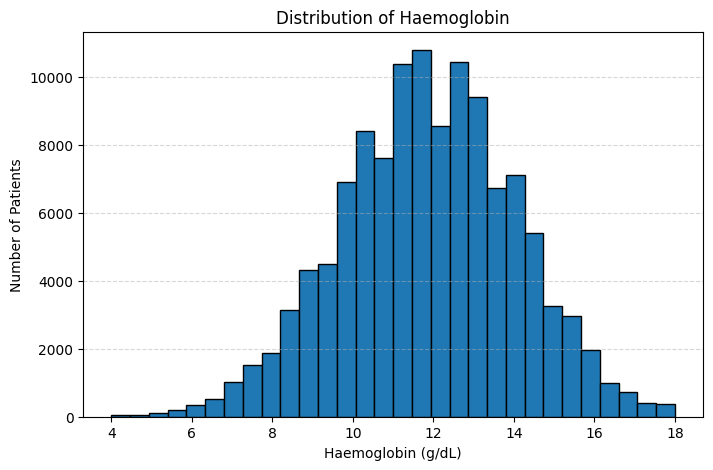

In [161]:
plt.figure(figsize=(8,5))

plt.hist(master_df["haemoglobin"], bins=30, edgecolor="black")

plt.title("Distribution of Haemoglobin")
plt.xlabel("Haemoglobin (g/dL)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

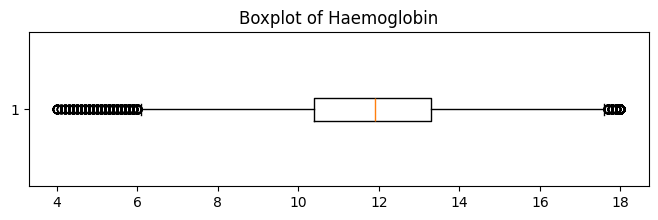

In [162]:
plt.figure(figsize=(8,2))

plt.boxplot(master_df["haemoglobin"], vert=False)

plt.title("Boxplot of Haemoglobin")

plt.show()

# Observation :

The haemoglobin distribution is approximately bell-shaped, with most patients having values between 10 and 14 g/dL. A small number of patients exhibit unusually low or high haemoglobin levels, which appear as outliers in the boxplot.

# Key Insight :

Patients with low haemoglobin levels may have underlying anaemia or chronic medical conditions that could delay recovery and increase the need for post-discharge care. Monitoring such patients may help reduce the risk of hospital readmission.

# systolic_bp

Systolic Blood Pressure (SBP) is the pressure in the arteries when the heart pumps blood.

In [163]:
master_df["systolic_bp"].describe()

,systolic_bp
count,120000.000000
mean,134.628075
std,20.756544
min,70.000000
25%,120.000000
50%,134.000000
75%,148.000000
max,220.000000


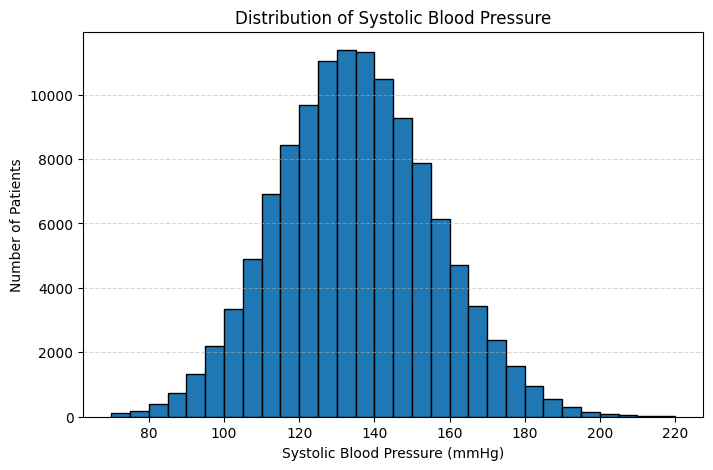

In [164]:
plt.figure(figsize=(8,5))

plt.hist(master_df["systolic_bp"], bins=30, edgecolor="black")

plt.title("Distribution of Systolic Blood Pressure")
plt.xlabel("Systolic Blood Pressure (mmHg)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

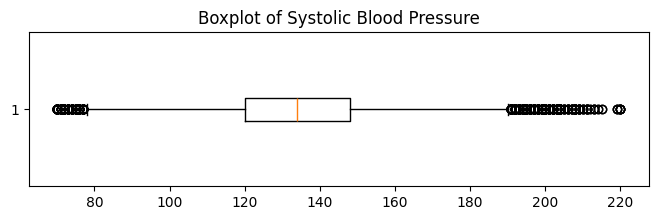

In [165]:
plt.figure(figsize=(8,2))

plt.boxplot(master_df["systolic_bp"], vert=False)

plt.title("Boxplot of Systolic Blood Pressure")

plt.show()

# Observation :

The systolic blood pressure distribution is approximately bell-shaped, with most patients having values between 110 and 150 mmHg. A small number of patients exhibit unusually low or high blood pressure values, which appear as outliers in the boxplot.

# Key Insight :

Patients with abnormal systolic blood pressure may have underlying cardiovascular instability or hypertension, which can increase clinical complexity. These patients may benefit from additional monitoring and appropriate follow-up after discharge to minimize the risk of hospital readmission.

# Patient History Variables :

prev_admissions : Number of previous hospital admissions before the current admission.

comorbidity_count : Number of chronic diseases a patient has.

diagnosis_count : Number of diagnoses assigned during the current admission.






In [166]:
master_df["prev_admissions"].describe()

,prev_admissions
count,120000.000000
mean,0.899183
std,1.081748
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,8.000000


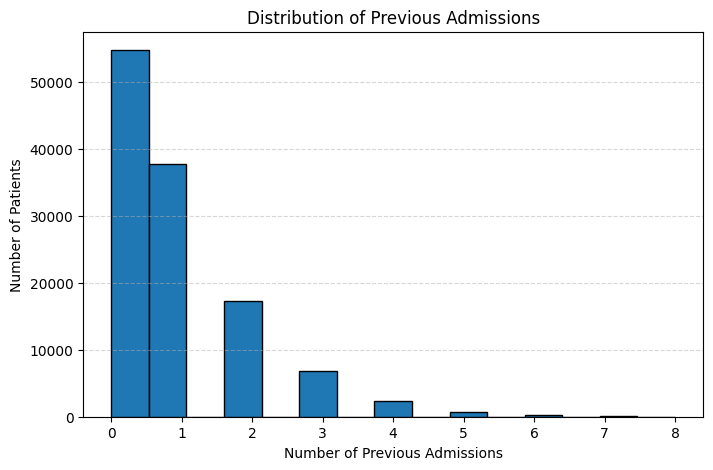

In [167]:
plt.figure(figsize=(8,5))

plt.hist(master_df["prev_admissions"], bins=15, edgecolor="black")

plt.title("Distribution of Previous Admissions")
plt.xlabel("Number of Previous Admissions")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Most patients are first-time or infrequent hospital visitors. However, patients with multiple previous admissions may have chronic illnesses or unresolved medical conditions, making them more likely to require readmission

In [168]:
master_df["comorbidity_count"].describe()

,comorbidity_count
count,120000.000000
mean,1.431975
std,1.508484
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,8.000000


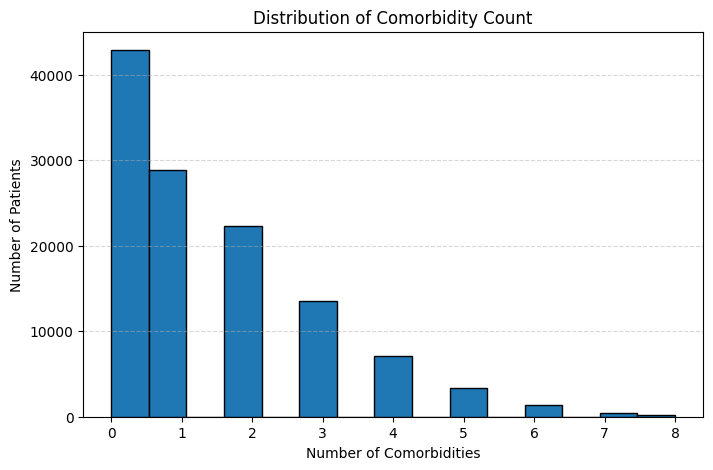

In [169]:
plt.figure(figsize=(8,5))

plt.hist(master_df["comorbidity_count"], bins=15, edgecolor="black")

plt.title("Distribution of Comorbidity Count")
plt.xlabel("Number of Comorbidities")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Most patients are first-time or infrequent hospital visitors. However, patients with multiple previous admissions may have chronic illnesses or unresolved medical conditions, making them more likely to require readmission

In [170]:
master_df["diagnosis_count"].describe()

,diagnosis_count
count,120000.000000
mean,2.261175
std,1.157536
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


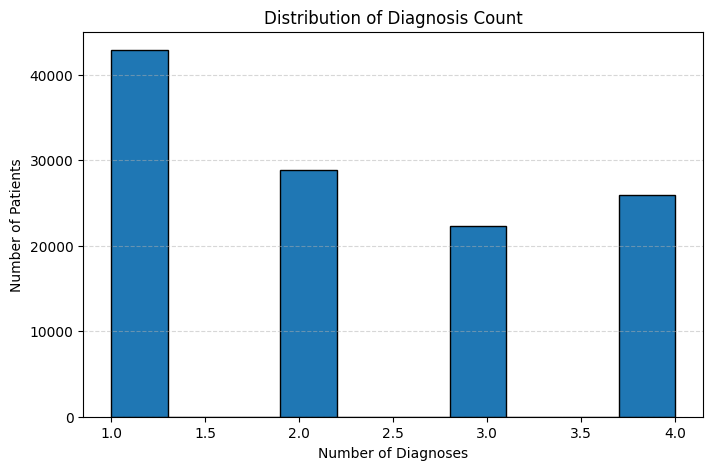

In [171]:
plt.figure(figsize=(8,5))

plt.hist(master_df["diagnosis_count"], bins=10, edgecolor="black")

plt.title("Distribution of Diagnosis Count")
plt.xlabel("Number of Diagnoses")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Patients with multiple chronic illnesses represent a clinically vulnerable population. Managing these patients effectively after discharge may reduce the likelihood of hospital readmission

# total_cost_inr

In [172]:
master_df["total_cost_inr"].describe()

,total_cost_inr
count,1.200000e+05
mean,9.577953e+04
std,1.955118e+05
min,6.490000e+02
25%,1.202300e+04
50%,3.097050e+04
75%,8.940700e+04
max,6.674008e+06


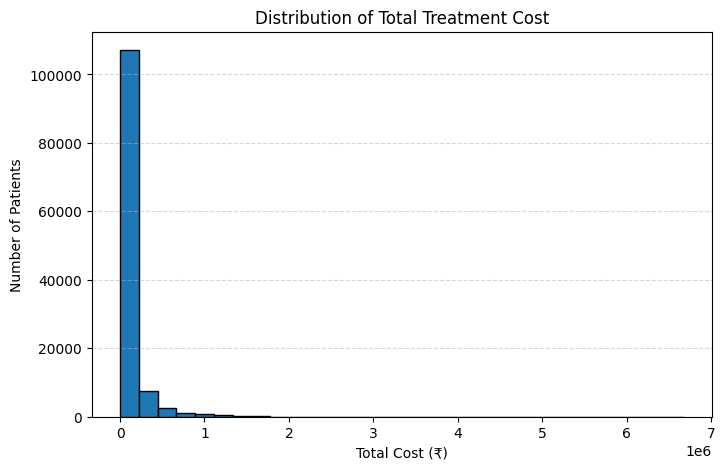

In [173]:
plt.figure(figsize=(8,5))

plt.hist(master_df["total_cost_inr"], bins=30, edgecolor="black")

plt.title("Distribution of Total Treatment Cost")
plt.xlabel("Total Cost (₹)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

govt_subsidy_inr


In [174]:
master_df["govt_subsidy_inr"].describe()

,govt_subsidy_inr
count,1.200000e+05
mean,4.760617e+04
std,1.062371e+05
min,0.000000e+00
25%,0.000000e+00
50%,1.214550e+04
75%,4.585575e+04
max,4.606120e+06


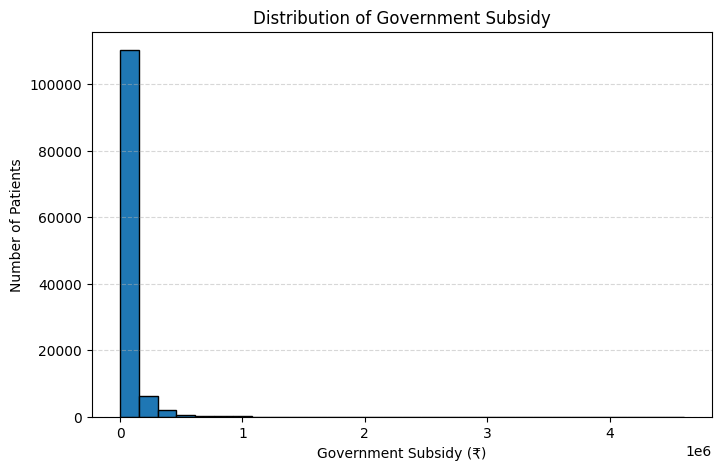

In [175]:
plt.figure(figsize=(8,5))

plt.hist(master_df["govt_subsidy_inr"], bins=30, edgecolor="black")

plt.title("Distribution of Government Subsidy")
plt.xlabel("Government Subsidy (₹)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# out_of_pocket_inr

In [176]:
master_df["out_of_pocket_inr"].describe()

,out_of_pocket_inr
count,1.200000e+05
mean,4.817336e+04
std,1.395519e+05
min,0.000000e+00
25%,0.000000e+00
50%,7.636000e+03
75%,3.334100e+04
max,4.648583e+06


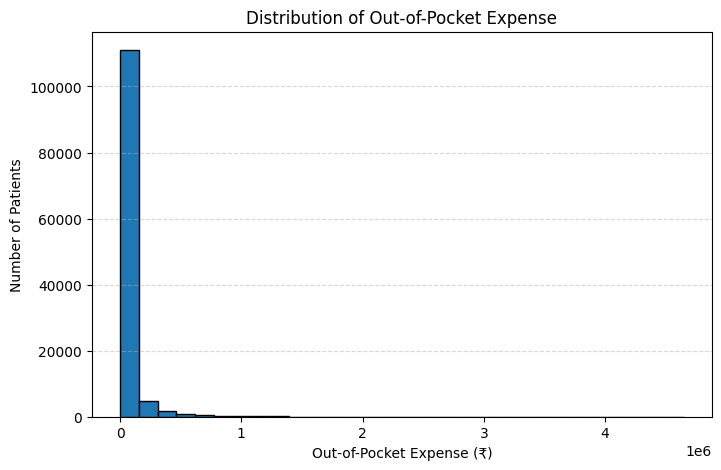

In [177]:
plt.figure(figsize=(8,5))

plt.hist(master_df["out_of_pocket_inr"], bins=30, edgecolor="black")

plt.title("Distribution of Out-of-Pocket Expense")
plt.xlabel("Out-of-Pocket Expense (₹)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

The analysis of patient history variables indicates that the majority of hospitalized patients have limited prior admissions and relatively few chronic conditions. However, a smaller subgroup demonstrates repeated hospitalizations, multiple comorbidities, and several diagnoses during a single admission, suggesting greater clinical complexity. These characteristics make them potential high-risk candidates for hospital readmission and highlight the importance of personalized post-discharge care strategies.

The financial analysis indicates that most hospital admissions involve moderate healthcare expenditure, while only a small subset of patients requires exceptionally expensive treatment. These high-cost admissions are likely associated with severe illnesses, prolonged hospitalization, multiple procedures, or complex medical conditions. Identifying these patients early can help hospitals optimize resource allocation, improve financial planning, and prioritize intensive post-discharge care to reduce avoidable readmissions

| Variable             | Distribution         | Outliers | Decision | Importance |
| -------------------- | -------------------- | -------- | -------- | ---------- |
| Age                  | Slightly left-skewed | No       | Retained | ⭐⭐⭐⭐       |
| Length of Stay       | Right-skewed         | Yes      | Retained | ⭐⭐⭐⭐⭐      |
| Number of Procedures | Right-skewed         | Yes      | Retained | ⭐⭐⭐⭐       |
| Charlson Index       | Discrete             | No       | Retained | ⭐⭐⭐⭐⭐      |
| HbA1c                | Right-skewed         | Yes      | Retained | ⭐⭐⭐⭐⭐      |
| Creatinine           | Right-skewed         | Yes      | Retained | ⭐⭐⭐⭐⭐      |
| Haemoglobin          | Approximately normal | Few      | Retained | ⭐⭐⭐⭐       |
| Systolic BP          | Approximately normal | Few      | Retained | ⭐⭐⭐⭐       |
| Previous Admissions  | Right-skewed         | No       | Retained | ⭐⭐⭐⭐       |
| Comorbidity Count    | Right-skewed         | No       | Retained | ⭐⭐⭐⭐⭐      |
| Diagnosis Count      | Discrete             | No       | Retained | ⭐⭐⭐⭐       |
| Financial Variables  | Right-skewed         | Yes      | Retained | ⭐⭐⭐⭐       |


In [183]:
master_df.select_dtypes(include=["object", "category"]).columns.tolist()

['admission_id',
 'patient_id',
 'admit_date',
 'discharge_date',
 'admit_type',
 'ward_type',
 'hospital_id',
 'discharge_type',
 'gender',
 'state',
 'insurance_type',
 'bill_id',
 'cost_category',
 'name',
 'state_hospital',
 'tier',
 'icd10_code',
 'diag_desc',
 'diag_category']

# Question 1

Which Diagnosis Category has the highest 30-Day Hospital Readmission Rate?

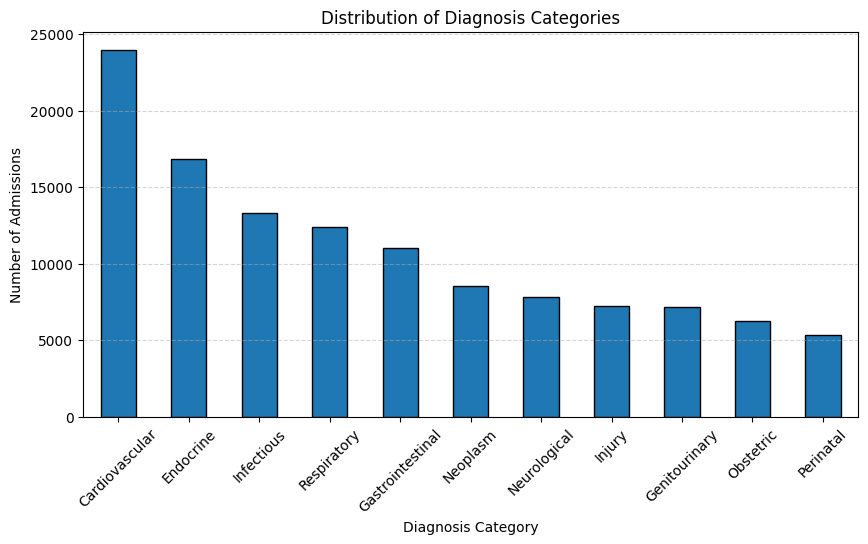

In [181]:
plt.figure(figsize=(10,5))

master_df["diag_category"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Diagnosis Categories")
plt.xlabel("Diagnosis Category")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

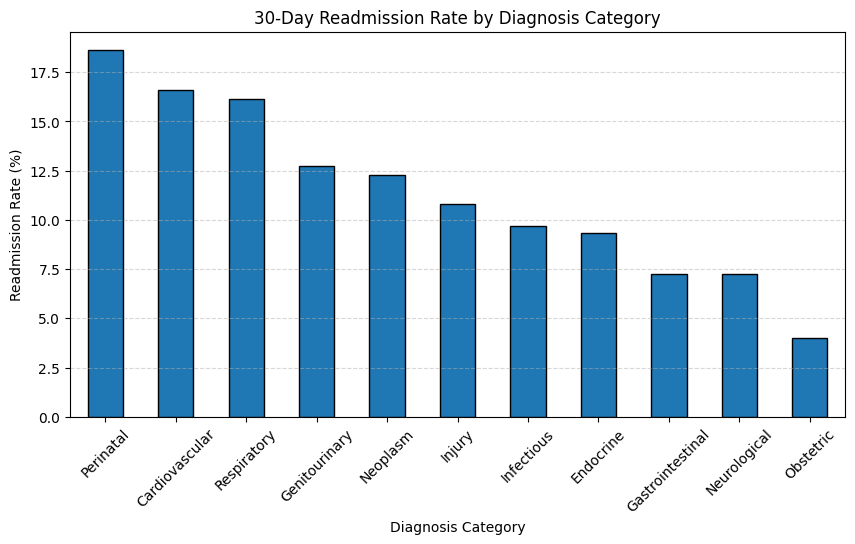

In [182]:
readmission_rate = (
    master_df.groupby("diag_category")["readmitted_30d"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,5))

readmission_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("30-Day Readmission Rate by Diagnosis Category")
plt.xlabel("Diagnosis Category")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Business Insight :

Although cardiovascular diseases account for the largest number of hospital admissions, perinatal conditions exhibit the highest 30-day readmission rate. This indicates that hospital administrators should prioritize both high-volume conditions (to manage workload) and high-risk conditions (to reduce readmissions). Resource allocation decisions should therefore consider readmission risk in addition to admission volume.

# Healthcare Recommendation :

Patients diagnosed with cardiovascular, respiratory, and perinatal conditions may benefit from enhanced discharge planning, early follow-up appointments, patient education, and remote monitoring programs. Such interventions could help reduce avoidable 30-day readmissions and improve patient outcomes.

# Question 2 :
Does the type of hospital admission influence the 30-day readmission rate?

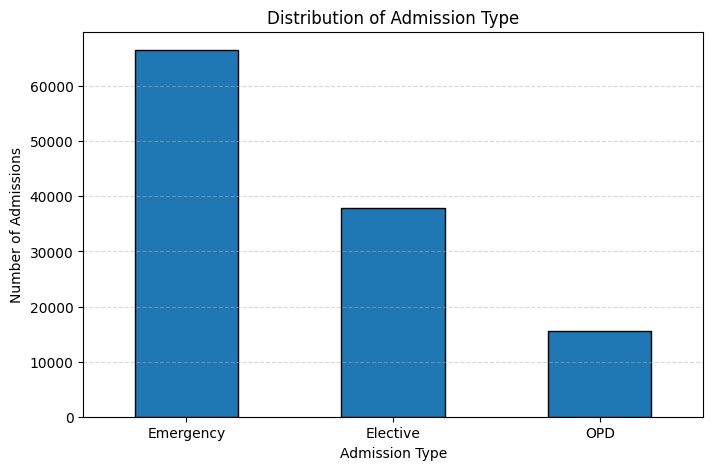

In [184]:
plt.figure(figsize=(8,5))

master_df["admit_type"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

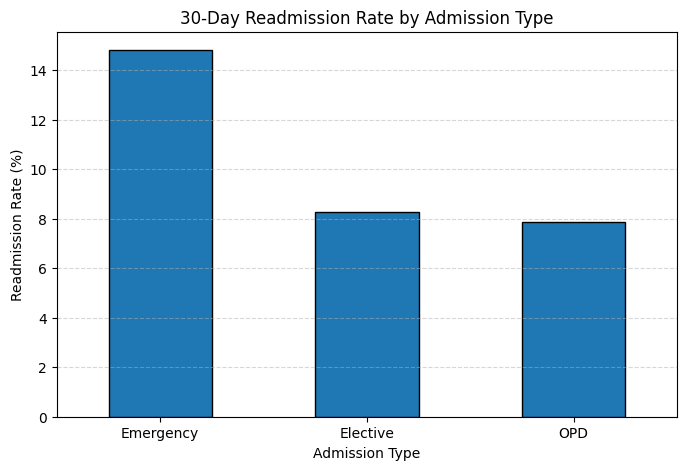

In [185]:
readmission_rate = (
    master_df.groupby("admit_type")["readmitted_30d"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

readmission_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("30-Day Readmission Rate by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Emergency admissions represent both the highest-volume and highest-risk patient group, with nearly double the 30-day readmission rate compared to elective and OPD admissions. This identifies emergency patients as a critical target for interventions aimed at reducing avoidable readmissions.

# Question 3 :
Does the Discharge Type Influence 30-Day Hospital Readmission?

In [186]:
master_df["discharge_type"].value_counts()

,count
discharge_type,
Recovered,87420
LAMA,15429
Referred,9738
Expired,7413


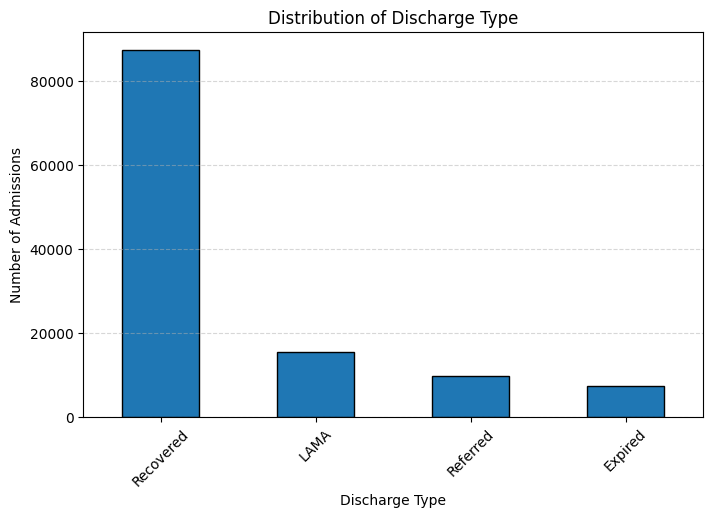

In [187]:
# LAMA : leave against medical advice

plt.figure(figsize=(8,5))

master_df["discharge_type"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Discharge Type")
plt.xlabel("Discharge Type")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

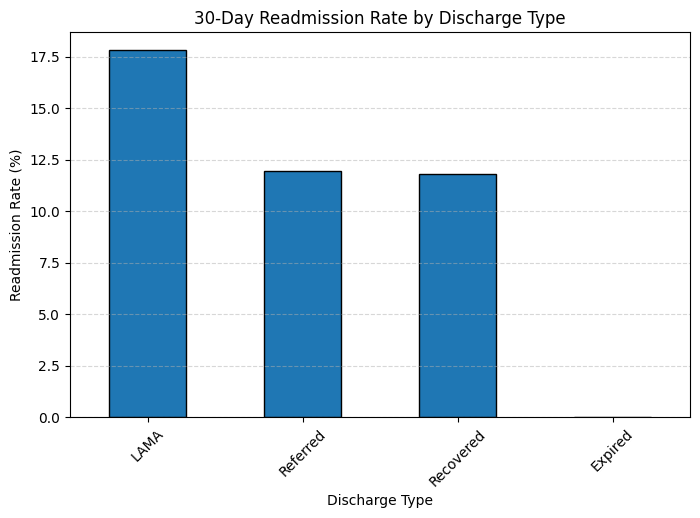

In [188]:
readmission_rate = (
    master_df.groupby("discharge_type")["readmitted_30d"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

readmission_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("30-Day Readmission Rate by Discharge Type")
plt.xlabel("Discharge Type")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Business Insight :

Patients leaving against medical advice exhibit the highest readmission rate among all discharge types. Since these patients may leave before completing treatment or without following medical recommendations, they are at greater risk of disease progression and subsequent readmission. Hospitals should focus on counseling these patients, addressing barriers to continued treatment, and strengthening discharge communication.

# Recommendation :

Hospitals should implement dedicated counseling and follow-up programs for patients intending to leave against medical advice. Understanding the reasons behind LAMA—such as financial constraints, family responsibilities, or dissatisfaction with care—could help reduce premature discharge and improve patient outcomes.

# Question 4 :
Does the Type of Hospital Ward Influence 30-Day Readmission?

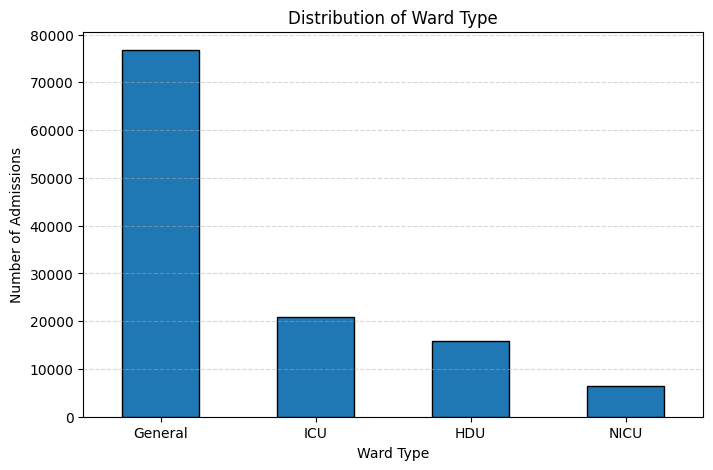

In [189]:
plt.figure(figsize=(8,5))

master_df["ward_type"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Ward Type")
plt.xlabel("Ward Type")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

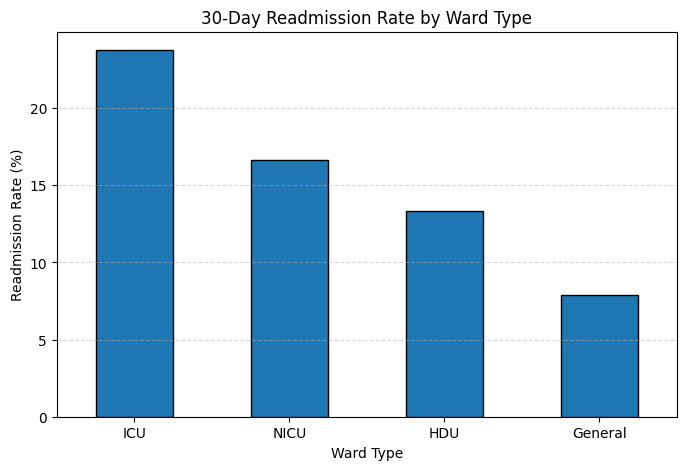

In [190]:
readmission_rate = (
    master_df.groupby("ward_type")["readmitted_30d"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

readmission_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("30-Day Readmission Rate by Ward Type")
plt.xlabel("Ward Type")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Key Insight :
Patients admitted to intensive care units are substantially more likely to be readmitted than patients treated in general wards.

# Question 5 :
Does Insurance Type Influence 30-Day Hospital Readmission?

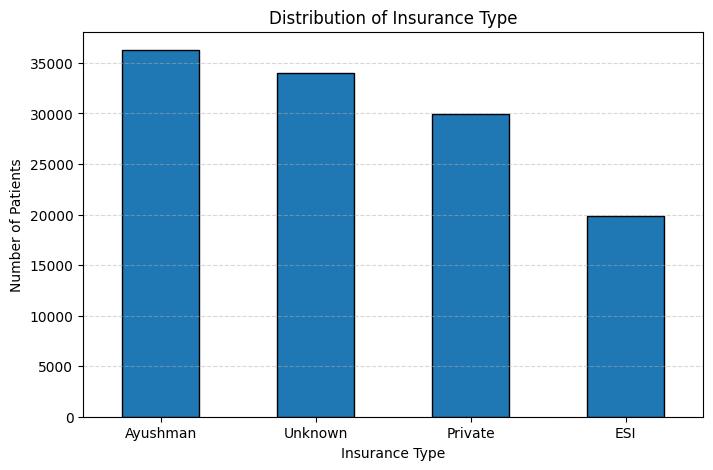

In [191]:
plt.figure(figsize=(8,5))

master_df["insurance_type"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

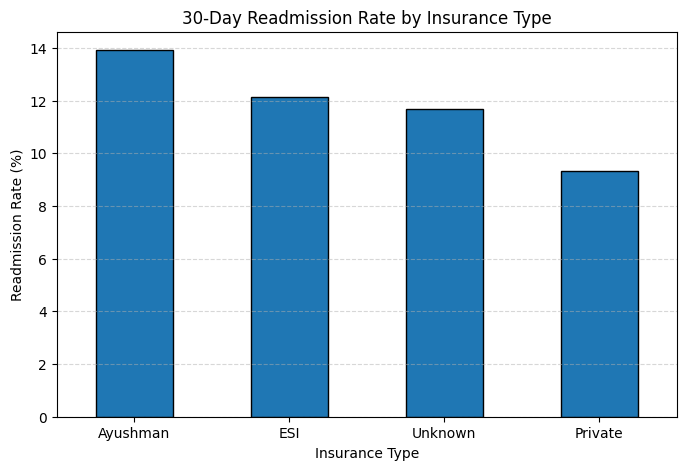

In [192]:
readmission_rate = (
    master_df.groupby("insurance_type")["readmitted_30d"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

readmission_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("30-Day Readmission Rate by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Note: The "Unknown" category represents records where insurance information was unavailable. Therefore, this category should be interpreted cautiously, as it may contain a mixture of different patient groups rather than a single insurance type.

# Insight :

Patients covered under the Ayushman scheme exhibit a slightly higher 30-day readmission rate compared with other insurance groups, while patients in the Private category show the lowest readmission rate. However, the differences are moderate, suggesting that insurance type alone is unlikely to be a strong driver of readmission. Clinical factors such as diagnosis, disease severity, ward type, and admission type are likely to have a greater influence.

# Recommendation :

Hospitals should avoid using insurance type as the primary criterion for identifying high-risk patients. Instead, insurance information should be considered alongside clinical indicators such as diagnosis category, admission type, and ward type when planning post-discharge care.

# Question 6 :
Does Treatment Cost Category Influence 30-Day Hospital Readmission?

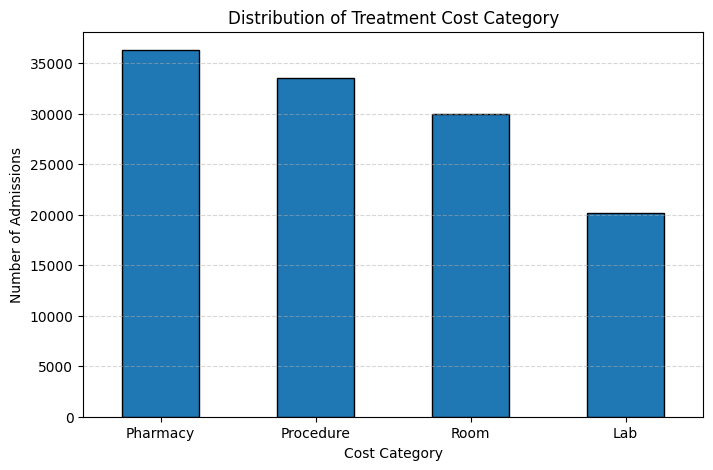

In [193]:
plt.figure(figsize=(8,5))

master_df["cost_category"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Treatment Cost Category")
plt.xlabel("Cost Category")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

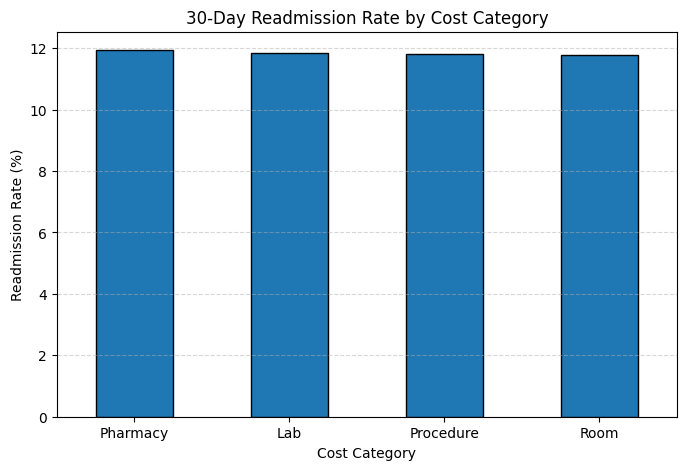

In [194]:
readmission_rate = (
    master_df.groupby("cost_category")["readmitted_30d"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

readmission_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("30-Day Readmission Rate by Cost Category")
plt.xlabel("Cost Category")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Business Insight :

The dominant treatment cost component does not appear to have a meaningful association with hospital readmission. This suggests that clinical factors such as diagnosis, illness severity, admission type, and ward type are likely to be much stronger determinants of readmission than the category of healthcare expenditure.

In [195]:
master_df.groupby("tier")["readmitted_30d"].mean()*100

,readmitted_30d
tier,
tier1,11.864816
tier2,11.929181
tier3,11.692443


In [196]:
master_df.groupby("teaching")["readmitted_30d"].mean()*100

,readmitted_30d
teaching,
False,11.684639
True,11.957387


In [197]:
master_df.groupby("bpl_card")["readmitted_30d"].mean()*100

,readmitted_30d
bpl_card,
False,10.624097
True,13.953064


# Question :
Does Socioeconomic Status (BPL Card) Influence 30-Day Readmission?

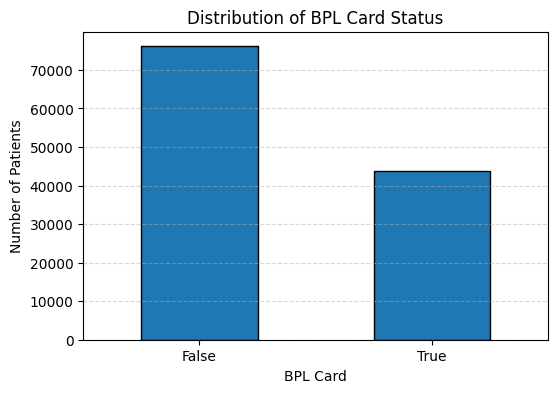

In [198]:
plt.figure(figsize=(6,4))

master_df["bpl_card"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of BPL Card Status")
plt.xlabel("BPL Card")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

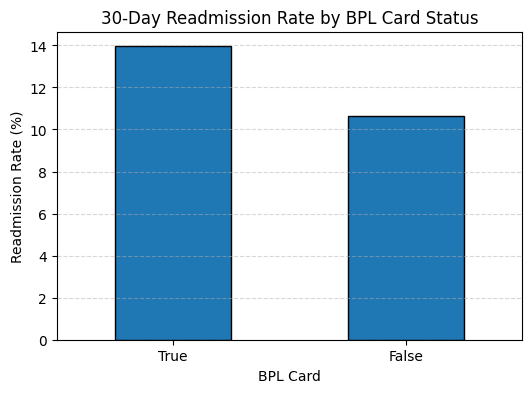

In [199]:
readmission_rate = (
    master_df.groupby("bpl_card")["readmitted_30d"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(6,4))

readmission_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("30-Day Readmission Rate by BPL Card Status")
plt.xlabel("BPL Card")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Hospitals may consider providing additional discharge support and follow-up services to patients identified through socioeconomic risk indicators, including BPL status. Such interventions could help reduce avoidable readmissions among vulnerable patient groups.

# Exploratory Data Analysis (EDA) Summary

The exploratory data analysis provided valuable insights into the characteristics of hospital admissions and the factors associated with 30-day patient readmission.

# Key Findings
The majority of hospitalized patients were middle-aged and elderly, with most admissions lasting less than 10 days.

Clinical indicators such as Charlson Comorbidity Index, HbA1c, Creatinine, previous admissions, and comorbidity count highlighted a subgroup of medically complex patients who are more likely to experience readmission.

Healthcare expenditure was highly right-skewed, with a small proportion of patients accounting for a large share of treatment costs.

# From the categorical analysis, several important patterns emerged :

Diagnosis category showed a strong relationship with readmission, with Perinatal, Cardiovascular, and Respiratory conditions exhibiting relatively higher readmission rates.

Emergency admissions had nearly twice the readmission rate of Elective and OPD admissions, indicating that patients admitted under urgent conditions require closer post-discharge monitoring.
Patients discharged Against Medical Advice (LAMA) experienced the highest readmission rate, emphasizing the importance of treatment completion and effective discharge counseling.

Patients treated in ICU and other high-dependency wards demonstrated substantially higher readmission rates than those treated in General Wards, suggesting that illness severity plays a significant role in readmission risk.

BPL card holders showed a higher readmission rate than non-BPL patients, indicating that socioeconomic factors may also contribute to post-discharge outcomes.

Variables such as Hospital Tier, Teaching Hospital status, and Treatment Cost Category exhibited minimal variation in readmission rates, suggesting that these factors have limited influence on readmission within this dataset.

In [201]:
from google.colab import files

master_df.to_csv("master_df.csv", index=False)
files.download("master_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>